In [ ]:
import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "your kaggle username",
    "key": "your kaggle key"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:10<00:00, 212MB/s]

Dataset ready!


In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


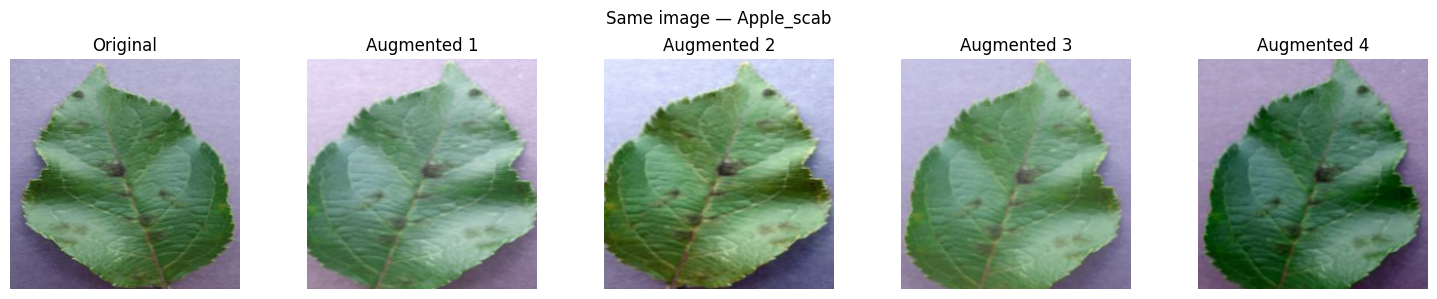

Every augmented version is still Apple_scab.
The label never changes — only the appearance does.


In [3]:
base_path = "plantvillage/plantvillage dataset/color"

# Load dataset WITHOUT transforms — just to grab raw images
raw_dataset = datasets.ImageFolder(base_path)
img_path, label_idx = raw_dataset.samples[0]
label_name = raw_dataset.classes[label_idx]

# Open raw image
img = Image.open(img_path).convert("RGB")

# Define augmentation transforms
augment = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),      # always flip for demo
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.3,
                           hue=0.1),
    transforms.RandomResizedCrop(224,
                                 scale=(0.8, 1.0))
])

# Show original + 4 augmented versions
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(img.resize((224, 224)))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented = augment(img)
    axes[i].imshow(augmented)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.suptitle(f"Same image — {label_name.split('___')[1]}", fontsize=12)
plt.tight_layout()
plt.show()

print("Every augmented version is still Apple_scab.")
print("The label never changes — only the appearance does.")

In [4]:
# OLD transform (what we used in day6)
old_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# NEW transform — augmentation added for training only
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),          # 50% chance of flipping
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2,
                           hue=0.1),            # slight colour shift
    transforms.RandomResizedCrop(224,
                                 scale=(0.8, 1.0)),  # random zoom/crop
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation NEVER gets augmentation — always clean images
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Why val never gets augmentation:")
print("Validation measures real-world performance.")
print("A farmer's phone camera won't randomly flip the image.")
print("So we test on clean images — always.")

Why val never gets augmentation:
Validation measures real-world performance.
A farmer's phone camera won't randomly flip the image.
So we test on clean images — always.


In [5]:
# Train and val need different transforms
# So we can't use random_split directly — we load twice

full_dataset = datasets.ImageFolder(base_path)
total = len(full_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

# Same split indices for both
torch.manual_seed(42)
train_indices, val_indices = torch.utils.data.random_split(
    range(total), [train_size, val_size]
)

# Apply different transforms
train_dataset = datasets.ImageFolder(base_path, transform=train_transform)
val_dataset   = datasets.ImageFolder(base_path, transform=val_transform)

train_dataset = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_dataset   = torch.utils.data.Subset(val_dataset,   val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 1358 | Val batches: 340


In [6]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(in_features=1280, out_features=38)

for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)
print(f"Model ready | Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 103MB/s]


Model ready | Trainable params: 48,678


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), 100. * correct / total

# --- Run 3 epochs ---
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
NUM_EPOCHS = 3

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = validate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1/3 | Train Loss: 0.6710 | Train Acc: 84.00% | Val Loss: 0.2770 | Val Acc: 92.03%
Epoch 2/3 | Train Loss: 0.3114 | Train Acc: 91.01% | Val Loss: 0.2248 | Val Acc: 93.07%
Epoch 3/3 | Train Loss: 0.2673 | Train Acc: 91.69% | Val Loss: 0.2169 | Val Acc: 93.31%


In [8]:
print("=== WITH vs WITHOUT Augmentation ===")
print()
print(f"Day 6 (no augmentation):")
print(f"  Epoch 3 → Train: 94.90% | Val: 96.62%")
print()
print(f"Day 10 (with augmentation):")
print(f"  Epoch 3 → Train: {history['train_acc'][-1]:.2f}% | Val: {history['val_acc'][-1]:.2f}%")
print()
print("Why train accuracy may be LOWER with augmentation:")
print("  Augmented images are harder — model sees different versions each time.")
print("  But val accuracy should be higher or equal — model generalises better.")

=== WITH vs WITHOUT Augmentation ===

Day 6 (no augmentation):
  Epoch 3 → Train: 94.90% | Val: 96.62%

Day 10 (with augmentation):
  Epoch 3 → Train: 91.69% | Val: 93.31%

Why train accuracy may be LOWER with augmentation:
  Augmented images are harder — model sees different versions each time.
  But val accuracy should be higher or equal — model generalises better.
